In [1]:
import pandas as pd

# Load your car data
df = pd.read_csv(r"C:\Users\sarthak\Downloads\archive 4\car data.csv")

# Display the first 5 rows of your dataset
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [3]:
# Print all column names
print(df.columns)


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')


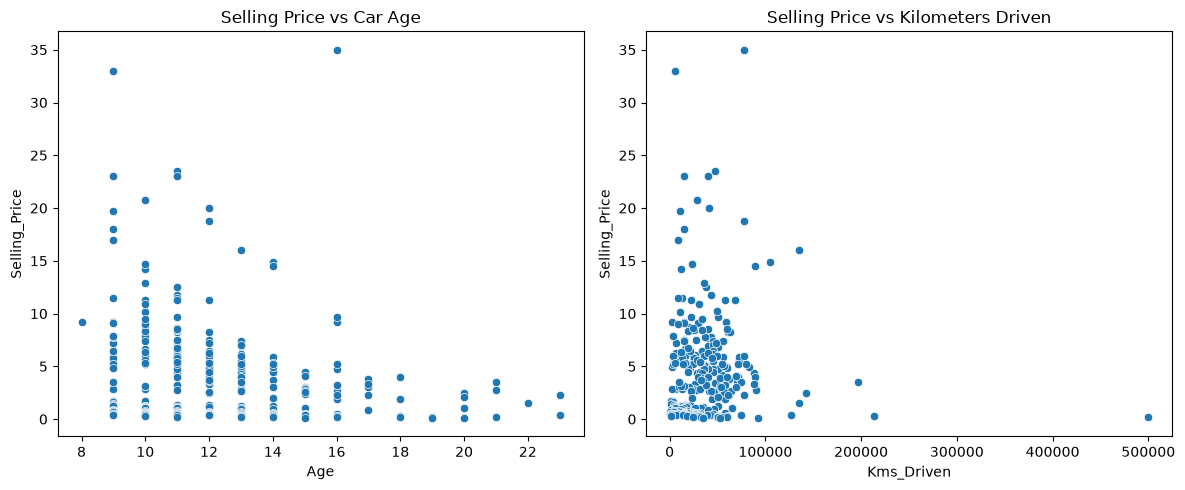

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. See how Age affects Selling Price
df['Age'] = 2026 - df['Year']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Age', y='Selling_Price')
plt.title('Selling Price vs Car Age')

# 2. See how Mileage (Kms_Driven) affects Selling Price
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price')
plt.title('Selling Price vs Kilometers Driven')

plt.tight_layout()
plt.show()

In [7]:
# Check for null values in each column
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Age              0
dtype: int64


In [8]:
# Create dummy variables for categorical columns
# We use drop_first=True to avoid the 'dummy variable trap'
df = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

# Let's see the new columns
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Owner  Age  \
0     ritz  2014           3.35           5.59       27000      0   12   
1      sx4  2013           4.75           9.54       43000      0   13   
2     ciaz  2017           7.25           9.85        6900      0    9   
3  wagon r  2011           2.85           4.15        5200      0   15   
4    swift  2014           4.60           6.87       42450      0   12   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0             False              True                   False   
1              True             False                   False   
2             False              True                   False   
3             False              True                   False   
4              True             False                   False   

   Transmission_Manual  
0                 True  
1                 True  
2                 True  
3                 True  
4                 True  


In [9]:
# 'y' is our target variable (Selling Price)
y = df['Selling_Price']

# 'X' contains all our features except the target and the car name
X = df.drop(columns=['Selling_Price', 'Car_Name'])

print("Features columns:", X.columns.tolist())

Features columns: ['Year', 'Present_Price', 'Kms_Driven', 'Owner', 'Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


In [10]:
from sklearn.model_selection import train_test_split

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}")

Training rows: 240, Testing rows: 61


In [11]:
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Train the model on our training data
lr_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ask the trained model to predict prices for the test data
y_pred = lr_model.predict(X_test)

# 2. Calculate the evaluation scores
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score (Accuracy): {r2:.2f}")

Mean Absolute Error: 1.22
R2 Score (Accuracy): 0.85


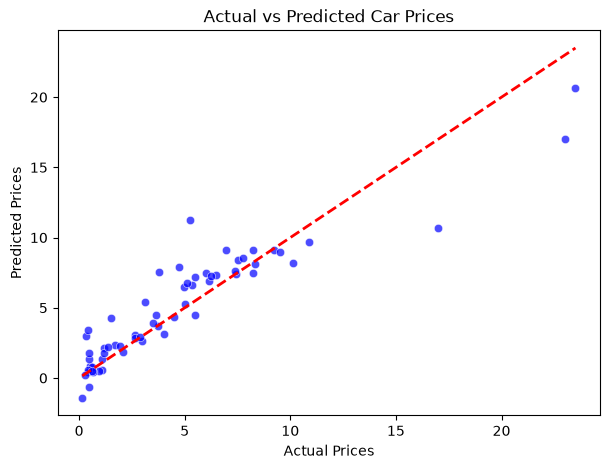

In [13]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Car Prices')
plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize and train the Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Make predictions using the new model
y_pred_rf = rf_model.predict(X_test)

# 3. Calculate scores
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest Metrics ---")
print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"R2 Score (Accuracy): {r2_rf:.2f}")

--- Random Forest Metrics ---
Mean Absolute Error: 0.60
R2 Score (Accuracy): 0.97


In [15]:
import joblib

# Save the winning Random Forest model to a file
joblib.dump(rf_model, 'car_price_model.pkl')
print("Model saved successfully as 'car_price_model.pkl'!")

Model saved successfully as 'car_price_model.pkl'!
